# Import

In [41]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
helper_dir = '../src/tf_activity/'
sys.path.append(helper_dir)
from helper import adata_lambda, net_lambda, calculate_tf_activity
sys.path.append(helper_dir)

datasets = ['data1', 'data7_allTPs_jalil']

# - color palette
color_palette = sns.color_palette("tab10", len(datasets))  
datasets_colors = {label: color for label, color in zip(datasets, color_palette)}

# - load data
if True:
    cell_type = 'CD8T'
    adata_complete = {dataset: adata_lambda(dataset) for dataset in datasets}
    adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
    nets_dict = {dataset: net_lambda(dataset, cell_type) for dataset in datasets}
    tf_acts_dict = {}
    for dataset in datasets:
        tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
        tf_acts_dict[dataset] = tf_acts

# - pathways
helper_dir = '../'
sys.path.append(helper_dir)
from src.utils.util import get_canonical_pathways
pathways_df = get_canonical_pathways()

from src.helper import surrogate_names, colors_blind


# - tf list 
task_grn_inference_dir = '../../task_grn_inference/'
tf_all = np.loadtxt(f'{task_grn_inference_dir}/resources/grn_benchmark/prior/tf_all.csv', dtype=str)

# Run for all cell types

In [43]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import sys 
sys.path.append('../')
from src.tf_activity.script import main as main_tf_activity
import pandas as pd
import numpy as np

cell_types = ['CD4T', 'CD8T', 'NK', 'B', 'MONO']

par = {
    # - global vars
    'cell_type': 'MONO',
    'datasets': ['data1', 'data7_allTPs_jalil'], # data7_allTPs_jalil
    'central_tf_q': .8,
    'predictor_age_q': .8,
    'use_pseudobulk': True,
}

stats_df_store = []
for cell_type in cell_types:
    par['cell_type'] = cell_type
    stats_df = main_tf_activity(par)
    stats_df['cell_type'] = cell_type
    stats_df_store.append(stats_df)
stats_all = pd.concat(stats_df_store)
stats_all.to_csv('../output/tf_activation/stats_all.csv', index=False)

Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.67, Spearman: 0.79
Final Model R²: 0.92, Spearman: 0.95
Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.61, Spearman: 0.75
Final Model R²: 0.84, Spearman: 0.91
Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.40, Spearman: 0.64
Final Model R²: 0.72, Spearman: 0.85
Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.43, Spearman: 0.65
Final Model R²: 0.71, Spearman: 0.84
Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.43, Spearman: 0.62
Final Model R²: 0.75, Spearman: 0.88


## Meta analysis

In [45]:
import subprocess
def check_signs(group):
    '''
    slope should be same for both datasets
    '''
    signs = group['slope'].apply(lambda x: 1 if x > 0 else -1 if x < 0 else 0)
    return signs.nunique() == 1
def check_common(group):
    '''
    p value should be given for both dastaets
    '''
    return group['pvalue'].nunique() == 2

def wrapper_meta_analysis(stats_all):
    stats_all = stats_all.groupby(['gene', 'cell_type']).filter(check_signs)
    stats_all = stats_all.groupby(['gene', 'cell_type']).filter(check_common)
    cell_types = stats_all['cell_type'].unique()
    df_meta_store = []
    for cell_type in cell_types:
        df = stats_all[stats_all['cell_type'] == cell_type]
        
        file_path = f'../output/tf_activation/stats_{cell_type}.csv'
        df.to_csv(file_path, index=False)
        out_path = f'../output/tf_activation/stats_{cell_type}_meta.csv'

        Rscript_file = '../src/tf_activity/meta_analysis.R'
        try:
            # Run the R script with the provided file paths
            result = subprocess.run(
                ["Rscript", Rscript_file, file_path, out_path],
                check=True,  # This will raise an exception if the command fails
                stdout=subprocess.PIPE,  # Capture standard output
                stderr=subprocess.PIPE   # Capture standard error
            )
            print(f"R script ran successfully for {cell_type}.")
            if result.stdout.decode():
                print("Output:", result.stdout.decode())  # Print the output of the R script
            
        except subprocess.CalledProcessError as e:
            # Handle errors in running the R script
            print(f"Error occurred while running R script: {e}")
            print(f"Return code: {e.returncode}")
            print(f"Error message: {e.stderr.decode()}")
            sys.exit(1)  # Exit the Python script with a non-zero status code
        except FileNotFoundError as fnf_error:
            # Handle case where Rscript is not found
            print(f"File not found error: {fnf_error}")
            sys.exit(1)
        except Exception as ex:
            # Handle any other unexpected errors
            print(f"Unexpected error: {ex}")
            sys.exit(1)
        df_meta = pd.read_csv(out_path)
        df_meta['cell_type'] = cell_type
        print(cell_type, df_meta.shape)
        df_meta_store.append(df_meta)
    print(len(df_meta_store))
    if df_meta_store:
        df_meta_all = pd.concat(df_meta_store)
    else:
        df_meta_all = pd.DataFrame() 
    return df_meta_all
stats_all_c = stats_all.copy()
stats_all_c.rename(columns={'p_value': 'pvalue', 'tf':'gene'}, inplace=True)
df_meta_all = wrapper_meta_analysis(stats_all_c)
df_meta_all.rename(columns={'gene': 'tf'}, inplace=True)
df_meta_all.head()

R script ran successfully for CD4T.
CD4T (93, 4)
R script ran successfully for CD8T.
CD8T (152, 4)
R script ran successfully for NK.
NK (51, 4)
R script ran successfully for B.
B (40, 4)
R script ran successfully for MONO.
MONO (165, 4)
5


,tf,meta_p,meta_p_adj,cell_type
0,AIRE,6.085452e-18,4.042479e-17,CD4T
1,ANXA1,2.089357e-10,3.965514e-10,CD4T
2,ANXA11,1.690232e-07,2.495104e-07,CD4T
3,ARID5B,1.505910e-13,3.785126e-13,CD4T
4,BACH2,3.942690e-16,1.594218e-15,CD4T


In [46]:
assert 'meta_p_adj' not in stats_all.columns, 'meta_p_adj already in df_meta_all'
stats_all = stats_all.merge(df_meta_all, on=['tf', 'cell_type'], how='left')

# Explanatory analysis of nets and tf acitivity

## GRN models

In [47]:

def compare_nets_plot(datasets, cell_types):
    """Compare and plot GRNs for each cell type between two datasets.

    Parameters:
    - datasets: list containing two datasets.
    - cell_types: list of cell types to analyze.

    Returns:
    - None (displays plots).
    """
    for cell_type in cell_types:
        # Get networks for this cell type from both datasets
        net1 = net_lambda(datasets[0], cell_type)
        net2 = net_lambda(datasets[1], cell_type)

        if net1 is None or net2 is None:
            continue  # Skip if no network exists for this cell type

        # Convert to sets of (source, target) pairs
        edges1 = set(map(tuple, net1[['source', 'target']].values))
        edges2 = set(map(tuple, net2[['source', 'target']].values))

        # Extract TFs (sources) and target genes
        tfs1, tfs2 = set(net1['source']), set(net2['source'])
        targets1, targets2 = set(net1['target']), set(net2['target'])

        # Compute statistics
        stats = {
            "Edges": [len(edges1 & edges2), len(edges1), len(edges2)],
            "TFs": [len(tfs1 & tfs2), len(tfs1 ), len(tfs2 )],
            "Targets": [len(targets1 & targets2), len(targets1), len(targets2)]
        }

        categories = ["Common", surrogate_names[datasets[0]], surrogate_names[datasets[1]]]

        # Create subplots (3 side-by-side)
        fig, axes = plt.subplots(1, 3, figsize=(6, 3), sharey=False)
        plot_titles = ["Edge", "TF", "Target"]
        colors = ['#2E86C1', '#E74C3C', '#27AE60']

        for i, (key, ax) in enumerate(zip(stats.keys(), axes)):
            sns.barplot(x=categories, y=stats[key], ax=ax, palette=colors)
            ax.set_title(plot_titles[i])
            ax.set_ylabel("Count")
            ax.set_xlabel("")
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)
            ax.spines[['top', 'right']].set_visible(False)
            ax.margins(x=0.1)
        fig.suptitle(f'{cell_type}', fontsize=12)
        plt.tight_layout()
        plt.show()
if False:
    compare_nets_plot(datasets, cell_types)

## Sig TFs

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compare_tfs_in_datasets(df):
    """Compare TFs for each cell type between two datasets.

    Parameters:
    - df: A DataFrame with columns 'cell_type', 'dataset', and 'tf'.

    Returns:
    - None (displays plots).
    """
    cell_types_local = df['cell_type'].unique()  # Get unique cell types
    datasets = df['dataset'].unique()  # Get unique datasets
    # Plot
    fig, axes = plt.subplots(1, 5, figsize=(12, 2.5), sharey=True)
    for ii, cell_type in enumerate(cell_types_local):
        # Filter the DataFrame for the current cell type
        df_cell_type = df[df['cell_type'] == cell_type]

        # Get the unique TFs for each dataset
        tfs_dataset1 = set(df_cell_type[df_cell_type['dataset'] == datasets[0]]['tf'])
        tfs_dataset2 = set(df_cell_type[df_cell_type['dataset'] == datasets[1]]['tf'])

        # Compute the common and unique TFs
        common_tfs = tfs_dataset1 & tfs_dataset2
        unique_to_net1 = tfs_dataset1 
        unique_to_net2 = tfs_dataset2 

        # Prepare data for plotting
        data = pd.DataFrame({
            'Category': ['Common', surrogate_names[datasets[0]], surrogate_names[datasets[1]]],
            'Count': [len(common_tfs), len(unique_to_net1), len(unique_to_net2)]
        })

        ax = axes[ii]
        sns.barplot(data=data, x='Category', y='Count', palette=['green', 'grey', 'blue'], ax=ax)
        ax.set_title(f'{cell_type}')
        ax.set_xlabel('')
        ax.set_ylabel('TF')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(x=0.1, y=0.1)

    plt.tight_layout()
    plt.suptitle('Sig. TFs', fontsize=12, y=1.05)
if False:
    stats_all_sig_dataset = stats_all[stats_all['p_value_adj'] < 0.05]
    compare_tfs_in_datasets(stats_all_sig_dataset)

## Discovery type overlap


In [49]:
if False:
    from matplotlib_venn import venn2, venn3
    import pandas as pd
    import matplotlib.pyplot as plt

    sys.path.append('../../')
    from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
    # --------------- add the type of discovery (age, centrality, pseudo) to the stats
    if False:
        stats_df["type"] = [[] for _ in range(len(stats_df))]
        for idx, row in stats_df.iterrows():
            tf = row["tf"]
            dataset = row["dataset"]
            tf_types = []

            if tf in top_central_tfs.get(dataset, []):
                tf_types.append("central")
            if tf in top_predictors_age.get(dataset, []):
                tf_types.append("age")
            if include_pseudo:
                if tf in top_predictors_pseudo.get(dataset, []):
                    tf_types.append("pseudo")

            stats_df.at[idx, "type"] = tf_types
    df = stats_all.copy()

    for cell_type in stats_all['cell_type'].unique():
        df = stats_all[stats_all['cell_type'] == cell_type]
        df = df.explode("type")[['tf', 'type']]
        df_dict = df.groupby(['type'])['tf'].apply(list).to_dict()
        interaction_df = create_interaction_df(df_dict)
        aa = plot_interactions(interaction_df)
        plt.title(f'Interaction between TFs and type {cell_type}', pad=40)

# Trajectory plot: TF acitvity with age

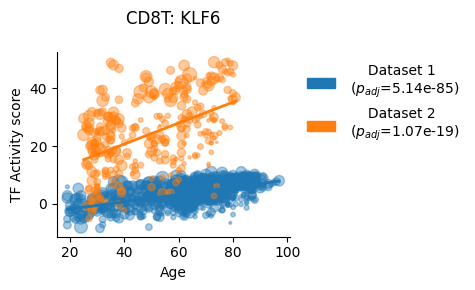

In [50]:
from helper import plot_trends
if True:
    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(genes, datasets, tf_acts_dict, datasets_colors, cell_type, surrogate_names=surrogate_names)
    plt.tight_layout()
    plt.savefig(f'../output/tf_activation/trends_{cell_type}_case.png', dpi=300)

# Positive/negative trends, all cell types

In [51]:
def add_supp_cols(df, pval_col='meta_p_adj', slope_col='slope', col='tf'):
    # Compute -log10(p_value_adj) for dot size
    df["neg_log10_adj_pval"] = -np.log10(df[pval_col])
    if 'linear_trend' in df.columns:
        df.drop('linear_trend', inplace=True, axis=1)
    # Determine color based on slope sign
    def determine_sign(x):
        if x.prod()<0:
            return "Inconsistent" 
        elif x.min() > 0:
            return "Increase"
        else:
            return "Decrease"
    linear_trend = df.groupby([col, 'cell_type'])[slope_col].apply(determine_sign).reset_index(name='linear_trend')
    linear_trend = linear_trend.dropna()

    # linear_trend = linear_trend[linear_trend.isna()]
 
    df = df.merge(linear_trend, on=[col, 'cell_type'], how='left')
    df["linear_trend"] = pd.Categorical(
        df["linear_trend"], 
        categories=["Increase", "Decrease", "Inconsistent"], 
        ordered=True
    )
    return df
stats_all_sig = stats_all[stats_all['meta_p_adj'] < 0.05]
stats_all_sig = add_supp_cols(stats_all_sig, pval_col='meta_p_adj', slope_col='slope')
df = stats_all_sig[['tf', 'cell_type', 'meta_p_adj', 'linear_trend', 'neg_log10_adj_pval']]
df = df[~df.duplicated()].reset_index(drop=True)
df_counts = df.groupby(['cell_type', 'linear_trend']).size().reset_index(name='Sig. TFs')
df_counts.head()

,cell_type,linear_trend,Sig. TFs
0,B,Increase,14
1,B,Decrease,14
2,B,Inconsistent,0
3,CD4T,Increase,78
4,CD4T,Decrease,10


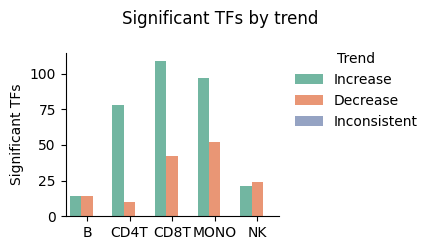

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(4.5, 2.5))
sns.barplot(data=df_counts, x='cell_type', y='Sig. TFs', hue='linear_trend', palette='Set2', ax=ax)
ax.set_ylabel('Significant TFs')
ax.set_xlabel('')
ax.legend(loc=(1.05, 0.5), title='Trend', frameon=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.suptitle('Significant TFs by trend', fontsize=12)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/trends.png', dpi=300)

# Interaction of sig TFs between different cell types

['CD8T', 'MONO', 'CD4T', 'NK', 'B']


Text(0.5, 1.0, 'Interaction between TFs and cell types')

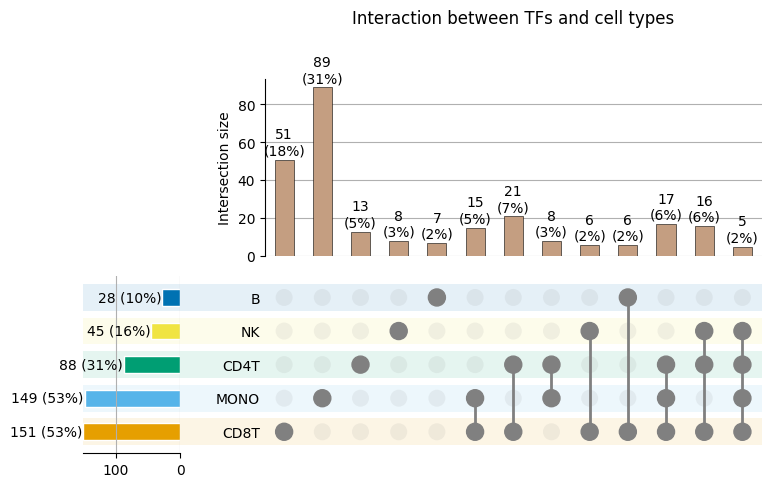

In [53]:
sys.path.append('../../')
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
df = stats_all_sig.copy()

df_dict = df.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_df, min_subset_size=5)
plt.title('Interaction between TFs and cell types', pad=40)

### Dotplot: common sig TFs 


In [54]:
tfs_shared = stats_all_sig.groupby(['tf']).size()>2
tfs_shared = tfs_shared[tfs_shared].index.to_numpy()
tfs_shared.shape


(115,)

Text(0.5, 0.95, 'Sig. TFs in ageing')

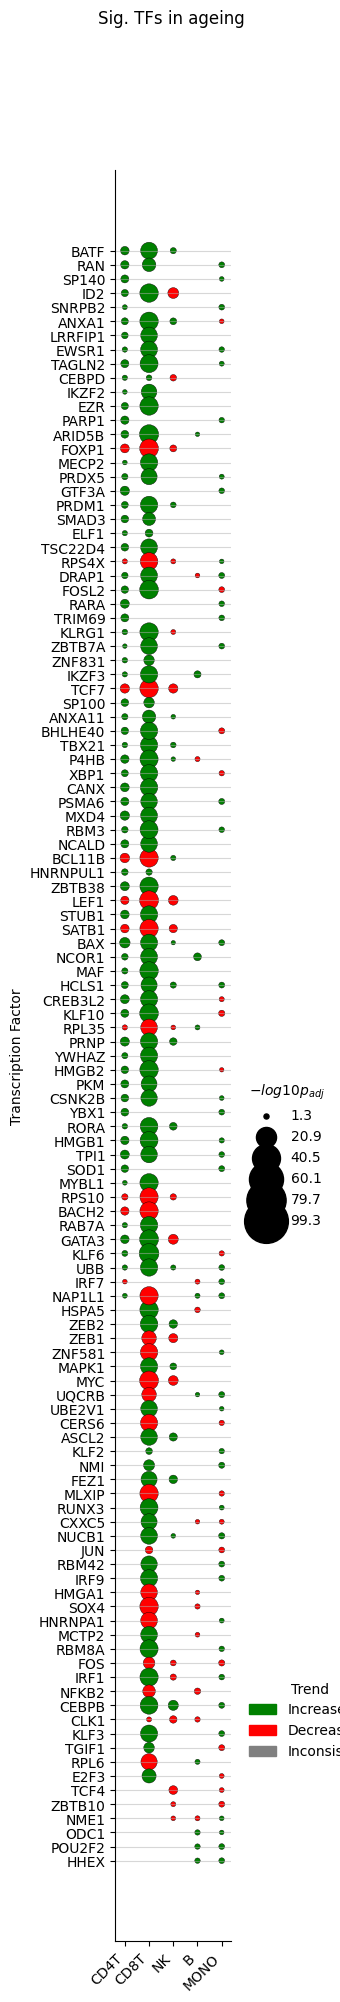

In [55]:

# - define a few functions 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def dotplot_tf_celltype(df, ax, color_col='linear_trend', size_col='neg_log10_adj_pval', title=None):
    if color_col is not None:
        palette = {name: color for name, color in zip(df[color_col].cat.categories, ["green", "red", "gray"])}
        color_legend = [mpatches.Patch(color=color, label=name) for name, color in palette.items()]
    else:
        palette = "tab10"
        color_legend = []
    # Capture scatter plot object
    scatter = sns.scatterplot(
        data=df, 
        x="cell_type", 
        y="tf", 
        size=size_col, 
        hue=color_col, 
        sizes=(10, 200),
        palette=palette, 
        edgecolor="black",
        legend=False,  # Disable automatic legend
        ax=ax
    )
    # Labels and formatting
    ax.set_ylabel("Transcription Factor")
    # ax.set_xlabel("Cell type")
    # ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel('')
    ax.margins(x=.1)
    ax.spines[['top','right']].set_visible(False)
    # 1. Create Color Legend 
    color_legend_handle = plt.legend(handles=color_legend, title={'linear_trend':r'Trend'}[color_col], loc=(1.1, .1), frameon=False)

    # 2. Create Size Legend 
    size_legend_values = np.linspace(df[size_col].min() , df[size_col].max(), num=6)
    size_legend_handles = [plt.scatter([], [], s=s * 10, color="black", label=f"{s:.1f}") for s in size_legend_values]
    size_legend_handle = plt.legend(handles=size_legend_handles, title={'neg_log10_adj_pval':r'$-log{10}{p_{adj}}$'}[size_col], loc=(1.1, .4), frameon=False)
    plt.gca().add_artist(color_legend_handle)

stats_all.reset_index(drop=True, inplace=True)
stats_all['cell_type'] = stats_all['cell_type'].astype('category')

if True: # subset to make the tf list shorter
    selected_tfs = tfs_shared
elif False:
    discovery_type = stats_all_sig['type'].explode()
    index_central = discovery_type[discovery_type=='central'].index
    stats_all_sig_central = stats_all_sig[stats_all_sig.index.isin(index_central)]
    selected_tfs = stats_all_sig_central['tf'].unique()
else:
    selected_tfs = stats_all_sig['tf'].unique()

fig, ax = plt.subplots(1, 1, figsize=(1.5, len(selected_tfs)*.2), 
                        #  gridspec_kw={'width_ratios': [.2, .2]}, 
                         sharey=True)# - plot TF activation stats
i = 0

# - plot TF activation stats
# ax = axes[i]
df_act = add_supp_cols(stats_all_sig, pval_col='meta_p_adj', slope_col='slope')[['tf', 'cell_type', 'linear_trend', 'neg_log10_adj_pval']]
df_act = df_act[~df_act.duplicated()].reset_index(drop=True)
dotplot_tf_celltype(df_act[df_act['tf'].isin(selected_tfs)], ax, color_col='linear_trend', size_col='neg_log10_adj_pval', title='TF activation')
ax.grid(axis='y', alpha=0.5)
ax.margins(y=0.05)
i+=1
# - plot TF exprssion stats

# ax = axes[i]
# df_exp = add_supp_cols(stats_all_sig, pval_col='meta_p_value_expression', slope_col='slope_expression')[['tf', 'cell_type', 'meta_p_adj', 'linear_trend', 'neg_log10_adj_pval']]
# df_exp = df_exp[~df_exp.duplicated()].reset_index(drop=True)
# dotplot_tf_celltype(df_exp[df_exp['tf'].isin(selected_tfs)], ax, color_col='linear_trend', size_col='neg_log10_adj_pval', title='TF expression')
# ax.grid(axis='y', alpha=0.5)
# i+=1

plt.suptitle("Sig. TFs in ageing", y=.95)

# TF activity trend vs expression in aging

In [56]:
from src.helper import determine_centrality

def add_centrality(df):
    """
        for a given df, compute the centrality of the TFs in the network, averaged over the two datasets, and subsetted to the TFs of interest
    """
    tfs = df['tf'].unique()
    cell_type = df['cell_type'].unique()
    assert len(cell_type) == 1
    cell_type = cell_type[0]

    net1 = net_lambda(datasets[0], cell_type)
    net2 = net_lambda(datasets[1], cell_type)

    net1_c = determine_centrality(net1, use_weight=False)
    net2_c = determine_centrality(net2, use_weight=False)

    net1_c['dataset'] = datasets[0]
    net2_c['dataset'] = datasets[1]

    c = pd.concat([net1_c, net2_c], axis=0)
    c = c[c.index.isin(tfs)]
    assert c.isna().any().any() == False
    c = c.reset_index().rename(columns={'index': 'tf'})
    c = c.groupby(['tf'])['centrality'].mean().reset_index()
    df = df.merge(c, on='tf', how='left')
    df['centrality'] = df['centrality'].div(df['centrality'].max())

    
    return df


In [57]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from helper import  determine_stats, adata_lambda

stats_store = []
for dataset in datasets:
    adata = adata_lambda(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
        sig_tfs_median_expression = np.median(adata_sub[:, sig_tfs].X.toarray(), axis=0)
        stats = []
        for tf, median_expression in zip(sig_tfs, sig_tfs_median_expression):
            stats.append({'tf': tf, 'median_expression': median_expression})
        stats = pd.DataFrame(stats)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_df = pd.concat(stats_store).reset_index(drop=True)
expression_df.head()

dataset: data1, cell_type: CD4T
dataset: data1, cell_type: CD8T
dataset: data1, cell_type: NK
dataset: data1, cell_type: B
dataset: data1, cell_type: MONO
dataset: data7_allTPs_jalil, cell_type: CD4T
dataset: data7_allTPs_jalil, cell_type: CD8T
dataset: data7_allTPs_jalil, cell_type: NK
dataset: data7_allTPs_jalil, cell_type: B
dataset: data7_allTPs_jalil, cell_type: MONO


,tf,median_expression,dataset,cell_type
0,BATF,2.309879,data1,CD4T
1,NPDC1,2.323331,data1,CD4T
2,RAN,4.313681,data1,CD4T
3,SP140,2.511806,data1,CD4T
4,ID2,4.124556,data1,CD4T


In [58]:
df_all = add_supp_cols(stats_all_sig, pval_col='meta_p_adj', slope_col='slope')[['tf', 'cell_type', 'meta_p_adj', 'linear_trend', 'neg_log10_adj_pval', 'dataset']]

df_all = df_all.merge(expression_df, on=['tf', 'cell_type', 'dataset'], how='left')

df_all.head(5)

,tf,cell_type,meta_p_adj,linear_trend,neg_log10_adj_pval,dataset,median_expression
0,BATF,CD4T,1.521981e-16,Increase,15.817591,data1,2.309879
1,NPDC1,CD4T,1.304561e-14,Increase,13.884536,data1,2.323331
2,RAN,CD4T,1.391259e-15,Increase,14.856592,data1,4.313681
3,SP140,CD4T,4.613587e-14,Increase,13.335961,data1,2.511806
4,ID2,CD4T,9.280180e-11,Increase,10.032444,data1,4.124556


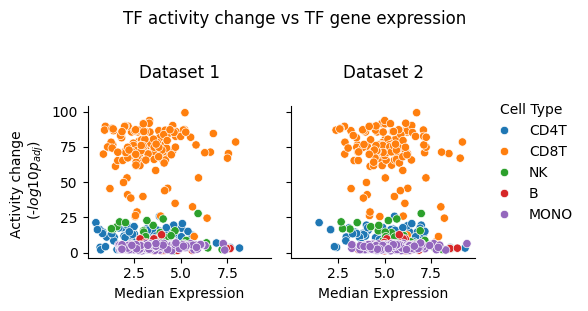

In [59]:
df = df_all
datasets = df["dataset"].unique()
n_datasets = len(datasets)

# Set up subplots
fig, axes = plt.subplots(1, n_datasets, figsize=(3 * n_datasets, 3), sharex=True, sharey=True)

# Loop through datasets and create scatter plots
for ax, dataset in zip(axes, datasets):
    subset = df[df["dataset"] == dataset]
    sns.scatterplot(data=subset, x="median_expression", y="neg_log10_adj_pval", hue="cell_type", ax=ax, legend=True)
    
    ax.set_title(surrogate_names[dataset], pad=20)
    ax.set_xlabel("Median Expression")
    ax.set_ylabel("Activity change \n (-$log10{p_{adj}}$)")
    ax.spines[['top', 'right']].set_visible(False)
    ax.get_legend().remove()
ax.legend(loc=(1.05, 0.2), title="Cell Type", frameon=False)
plt.suptitle("TF activity change vs TF gene expression", y=1.02)
plt.tight_layout()
plt.show()

# TF activity trend vs expression trend in aging

In [60]:
# --------------- add the stats obtained from expression data (rather than TF activity)
from helper import  determine_stats, adata_lambda

stats_store = []
for dataset in datasets:
    adata = adata_lambda(dataset)
    for cell_type in cell_types:
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        stats_all_sig_df = stats_all_sig[stats_all_sig['cell_type'] == cell_type]
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        sig_tfs = stats_all_sig_df['tf'].unique()
    
        stats = determine_stats(adata_sub, sig_tfs)
        stats['dataset'] = dataset
        stats['cell_type'] = cell_type
        stats_store.append(stats)
expression_stats_all = pd.concat(stats_store).reset_index(drop=True)
expression_stats_all.head()

dataset: data1, cell_type: CD4T
dataset: data1, cell_type: CD8T
dataset: data1, cell_type: NK
dataset: data1, cell_type: B
dataset: data1, cell_type: MONO
dataset: data7_allTPs_jalil, cell_type: CD4T
dataset: data7_allTPs_jalil, cell_type: CD8T
dataset: data7_allTPs_jalil, cell_type: NK
dataset: data7_allTPs_jalil, cell_type: B
dataset: data7_allTPs_jalil, cell_type: MONO


,tf,p_value,p_value_adj,slope,r2,intercept,spearman_corr,spearman_p,dataset,cell_type
0,BATF,5.950575e-01,1.000000e+00,0.000336,0.000289,2.270334,-0.009412,7.684351e-01,data1,CD4T
1,NPDC1,5.416247e-08,4.766297e-06,0.004843,0.029759,1.974766,0.188135,2.882313e-09,data1,CD4T
2,RAN,5.946844e-01,1.000000e+00,0.000244,0.000289,4.302136,0.008894,7.808339e-01,data1,CD4T
3,SP140,5.364233e-23,4.720525e-21,0.004247,0.094846,2.238258,0.291815,1.037567e-20,data1,CD4T
4,ID2,1.207088e-02,1.000000e+00,-0.001640,0.006418,4.230078,-0.073711,2.094906e-02,data1,CD4T


In [61]:
# - merge activation with expression sig stats
stats_all_sig_both = stats_all_sig.merge(expression_stats_all[['tf', 'slope', 'p_value', 'dataset', 'cell_type']], on=['tf', 'cell_type' ,'dataset'], suffixes=('', '_expression'), how='left')
stats_all_sig_both.head()


,tf,p_value,p_value_adj,slope,r2,intercept,spearman_corr,spearman_p,dataset,cell_type,meta_p,meta_p_adj,neg_log10_adj_pval,slope_expression,p_value_expression
0,BATF,2.297722e-07,3.745286e-05,0.002974,0.026982,-5.336612,0.138317,1.376276e-05,data1,CD4T,3.109423e-17,1.521981e-16,15.817591,0.000336,5.950575e-01
1,NPDC1,3.569265e-06,5.817901e-04,0.004286,0.021716,0.537752,0.119086,1.851758e-04,data1,CD4T,3.927709e-15,1.304561e-14,13.884536,0.004843,5.416247e-08
2,RAN,8.037382e-03,1.000000e+00,0.005127,0.007154,20.640552,0.067092,3.563447e-02,data1,CD4T,3.291151e-16,1.391259e-15,14.856592,0.000244,5.946844e-01
3,SP140,2.506912e-13,4.086267e-11,0.000225,0.053267,0.328931,0.194373,8.313074e-10,data1,CD4T,1.587471e-14,4.613587e-14,13.335961,0.004247,5.364233e-23
4,ID2,1.889896e-09,3.080531e-07,0.001217,0.036205,1.474842,0.162777,2.958854e-07,data1,CD4T,4.689983e-11,9.280180e-11,10.032444,-0.001640,1.207088e-02


In [62]:
stats_all_sig_both['signed_-log10_pval'] = (-np.log10(stats_all_sig_both['p_value'])) * np.sign(stats_all_sig_both['slope'])
stats_all_sig_both['signed_-log10_pval_exp'] = (-np.log10(stats_all_sig_both['p_value_expression'])) * np.sign(stats_all_sig_both['slope_expression'])

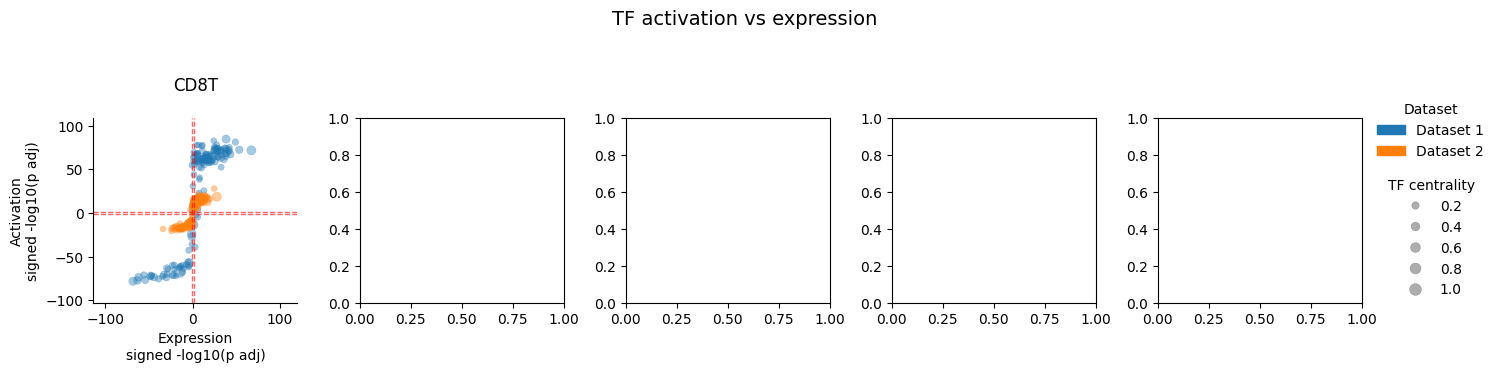

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cell_types_local = stats_all_sig_both["cell_type"].unique()
fig, axes = plt.subplots(1, len(cell_types_local), figsize=(15, 3.5), sharey=False, sharex=False)

palette = {name: color for name, color in zip(stats_all_sig_both["dataset"].unique(), color_palette)}
col_x = 'signed_-log10_pval_exp'
col_y = 'signed_-log10_pval'
# for i, cell_type in enumerate(cell_types_local):
for i, cell_type in enumerate(['CD8T']):
    ax = axes[i]
    df_cell_type = stats_all_sig_both[stats_all_sig_both["cell_type"] == cell_type]
    
    df_cell_type = add_centrality(df_cell_type) 
   
    # Plot scatter with correct color mapping
    sns.scatterplot(
        data=df_cell_type,
        x=col_x,
        y=col_y,
        palette=palette,  # Use the consistent color mapping
        size="centrality",
        hue="dataset",
        # sizes=(20, 100),
        edgecolor=None,
        alpha=0.4,
        ax=ax,
    )

    # Set the limits to be the same for both axes
    xmin, xmax = df_cell_type[col_x].min(), df_cell_type[col_x].max()
    ymin, ymax = df_cell_type[col_y].min(), df_cell_type[col_y].max()

    global_min = min(xmin, ymin)
    global_max = max(xmax, ymax)

    placed_positions = []

    if i == 0:
        
        ax.set_ylabel("Activation\nsigned -log10(p adj)")
    else:
        ax.set_ylabel("")
    ax.set_xlabel("Expression\nsigned -log10(p adj)")
    ax.get_legend().remove()  # Remove legend from individual plot

    ax.set_title(cell_type, pad=20)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_aspect("equal", adjustable="datalim")

    # Define padding as a percentage of the total range
    padding = 0.15 * (global_max - global_min)

    # Apply the same limits to both axes
    ax.set_xlim(global_min - padding, global_max + padding)
    ax.set_ylim(global_min - padding, global_max + padding)
    # Add significance threshold lines
    sig_threshold = 1.3
    ax.axvline(sig_threshold, linestyle="--", color="red", alpha=0.6, linewidth=1)  # Vertical
    ax.axvline(-sig_threshold, linestyle="--", color="red", alpha=0.6, linewidth=1)  # Vertical
    ax.axhline(sig_threshold, linestyle="--", color="red", alpha=0.6, linewidth=1)  # Horizontal
    ax.axhline(-sig_threshold, linestyle="--", color="red", alpha=0.6, linewidth=1)  # Horizontal

handles, labels = ax.get_legend_handles_labels()
# Create color legend for linear_trend
color_legend = [mpatches.Patch(color=palette[name], label=surrogate_names[name]) for name in palette]
color_legend_handle = plt.legend(handles=color_legend, title='Dataset', loc=(1.05, .75), frameon=False)

# Create size legend for TF centrality
size_legend_handle = plt.legend(handles=handles[-5:], labels=labels[-5:], title="TF centrality", 
                                loc=(1.1, 0),  frameon=False)

# Add the color legend manually after the size legend
plt.gca().add_artist(color_legend_handle)


plt.suptitle("TF activation vs expression", y=1.05, fontsize=14)
plt.tight_layout()
plt.savefig(f'../output/tf_activation/activation_vs_expression.png', dpi=300)

# TF-gene interactions 

## Consensus net across datasets


In [64]:
cyto_dir = '../output/tf_activation/cytoscape/'
os.makedirs(cyto_dir, exist_ok=True)

sig_nets_dict = {}
sig_nets_extended_dict = {}
for cell_type in stats_all_sig['cell_type'].unique():
    sig_tfs = stats_all_sig[stats_all_sig['cell_type'] == cell_type]['tf'].unique()
    net1 = net_lambda(datasets[0], cell_type)
    net2 = net_lambda(datasets[1], cell_type)
    net1['dataset'] = datasets[0]
    net2['dataset'] = datasets[1]
    net = pd.concat([net1, net2], axis=0)
    net['link'] = net['source'] + '_' + net['target']
    net = net[net['source'].isin(sig_tfs)]
    

    # - subset the tfs to the common ones
    edges_n = net.groupby('link')['weight'].size()
    assert edges_n.max() == 2 and edges_n.min() == 1
    print('\n Stats of common and unique edges: \t ', edges_n.value_counts()) #TODO: plot this
    if True: # only shared edges
        edges_common = edges_n[edges_n == 2].index 
    else:
        edges_common = edges_n[edges_n >=1].index 

    net = net[net['link'].isin(edges_common)].reset_index(drop=True)

    # - check consistency of regulation between the two datasets
    def check_consistency(values):
        if values.prod() < 0:
            return 'Inconsistent'
        else:
            return 'Consistent'
    con = net.groupby(['link'])['weight'].apply(check_consistency)
    print('\n Number of consistent vs inconsistent: ', con.value_counts()) #TODO: plot this
    con_edges = con[con == 'Inconsistent'].index
    net = net[~net['link'].isin(con_edges)].reset_index(drop=True)
    
    #- take the mean weight of the edges between the two datasets
    net = net.groupby(['source','target'])['weight'].mean().reset_index()
    sig_nets_dict[cell_type] = net

    # - save 
    # net.to_csv(f'{cyto_dir}/net_{cell_type}.csv', index=False)


 Stats of common and unique edges: 	  weight
1    4756
2    1624
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent      1622
Inconsistent       2
Name: count, dtype: int64

 Stats of common and unique edges: 	  weight
1    16818
2     6508
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent      6504
Inconsistent       4
Name: count, dtype: int64

 Stats of common and unique edges: 	  weight
1    1668
2     670
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent    670
Name: count, dtype: int64

 Stats of common and unique edges: 	  weight
1    2980
2     200
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent      198
Inconsistent      2
Name: count, dtype: int64

 Stats of common and unique edges: 	  weight
1    27176
2     9988
Name: count, dtype: int64

 Number of consistent vs inconsistent:  weight
Consistent      9777
Inconsistent     211
Name: co

## In-degree centrality of target genes

In [65]:
top_target_n = 20
top_targets_df = []
for i, (cell_type, net_o) in enumerate(sig_nets_dict.items()):
    # - determine in-degree centality
    net = net_o.copy()
    net['source_'] = net['source']
    net['source'] = net['target']
    net['target'] = net['source_']
    net.drop('source_', axis=1, inplace=True)

    c = determine_centrality(net, use_weight=False)
    c = c.sort_values('centrality', ascending=False)[:top_target_n]
    c['cell_type'] = cell_type
    top_targets_df.append(c)
top_targets_df = pd.concat(top_targets_df)
top_targets_df['is_tf'] = top_targets_df.index.isin(tf_all)
top_targets_df['is_tf'] = top_targets_df['is_tf'].replace({True: 'TF', False: 'Non-TF'})
top_targets_df['is_tf'] = top_targets_df['is_tf'].astype('category')
top_targets_df.head()

,centrality,cell_type,is_tf
KLF6,0.422274,CD4T,TF
ANXA1,0.401392,CD4T,TF
RPS4X,0.389791,CD4T,TF
FOXP3,0.174014,CD4T,TF
RORA,0.169374,CD4T,TF


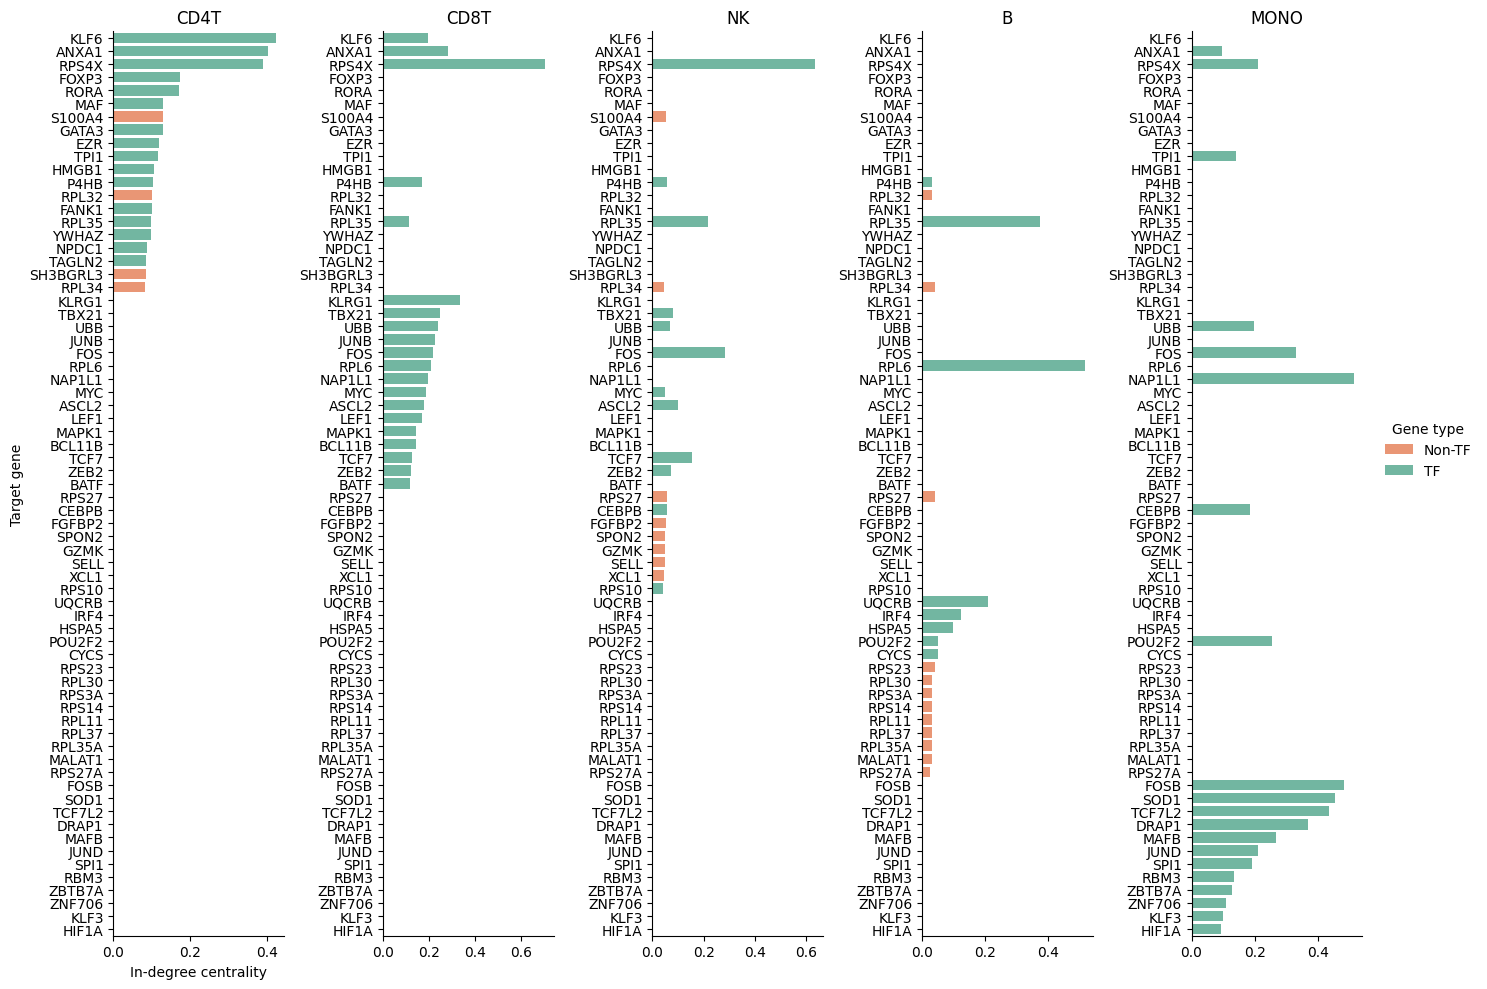

In [66]:
fig, axes = plt.subplots(1, 5, figsize=(15, 10), sharey=True)
for i, (cell_type) in enumerate(top_targets_df['cell_type'].unique()):
    c = top_targets_df[top_targets_df['cell_type'] == cell_type]
    palette = {key:color for key, color in zip(['TF', 'Non-TF'], sns.color_palette("Set2", 2))} 
    ax = axes[i]
    sns.barplot(data=c, x='centrality', y=c.index, hue='is_tf', dodge=False, ax=ax, palette=palette)

    ax.set_ylabel('Target gene' if i == 0 else "")  # Only label the first plot
    ax.set_xlabel('In-degree centrality')
    ax.set_title(cell_type)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(labelleft=True)
    ax.get_legend().remove()  # Remove legend from individual plot
    if i != 0:
        ax.set_ylabel('')
        ax.set_xlabel('')
ax.legend(title="Gene type", loc=(1.1, 0.5), frameon=False)

plt.tight_layout()

## Regulatory communities

In [67]:
def identify_modules(df):
    import networkx as nx
    import igraph as ig
    import leidenalg as la
    weight_o = df['weight'].copy()
    df['weight'] = df['weight'].abs()
    G = nx.from_pandas_edgelist(df, 'source', 'target', ['weight'])

    # Convert to igraph (better for community detection)
    ig_graph = ig.Graph.TupleList(df.itertuples(index=False), directed=True, edge_attrs=["weight"])

    # Apply Leiden clustering
    partition = la.find_partition(ig_graph, la.RBConfigurationVertexPartition, weights="weight")

    # Extract module assignments
    df['module'] = [partition.membership[ig_graph.vs.find(name=n).index] for n in df['source']]
    df['weight'] = weight_o
    return df

modules_store = []
for cell_type in sig_nets_dict.keys():
    net = sig_nets_dict[cell_type]
    net = identify_modules(net.copy())
    net['cell_type'] = cell_type
    modules_store.append(net)
modules_df = pd.concat(modules_store)
modules_df.head()

,source,target,weight,module,cell_type
0,AIRE,ALOX5AP,0.059047,3,CD4T
1,AIRE,ANXA2,0.098634,3,CD4T
2,AIRE,B2M,0.074761,3,CD4T
3,AIRE,CAPG,0.068111,3,CD4T
4,AIRE,CCR10,0.104114,3,CD4T


In [68]:
modules_df['weight'].min()

-0.56056682355412

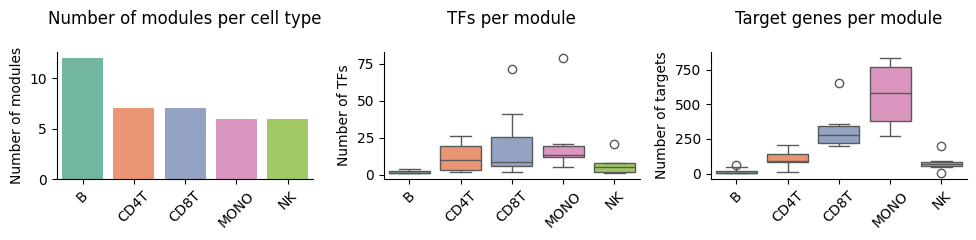

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Count number of modules per cell type
module_counts = modules_df.groupby('cell_type')['module'].nunique().reset_index()
module_counts.columns = ['cell_type', 'num_modules']

# Count number of TFs per module
tfs_per_module = modules_df.groupby(['cell_type', 'module'])['source'].nunique().reset_index()
tfs_per_module.columns = ['cell_type', 'module', 'num_tfs']

# Count number of target genes per module
targets_per_module = modules_df.groupby(['cell_type', 'module'])['target'].nunique().reset_index()
targets_per_module.columns = ['cell_type', 'module', 'num_targets']

# Merge into a summary table
module_stats = pd.merge(tfs_per_module, targets_per_module, on=['cell_type', 'module'])
module_stats = pd.merge(module_stats, module_counts, on='cell_type')

# Plot statistics
fig, axes = plt.subplots(1, 3, figsize=(10, 2.5))

# Number of modules per cell type
sns.barplot(data=module_counts, x="cell_type", y="num_modules", ax=axes[0], palette="Set2")
axes[0].set_title("Number of modules per cell type", pad=20)
axes[0].set_ylabel("Number of modules")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)
axes[0].set_xlabel("")

# Number of TFs per module (boxplot)
sns.boxplot(data=module_stats, x="cell_type", y="num_tfs", ax=axes[1], palette="Set2")
axes[1].set_title("TFs per module", pad=20)
axes[1].set_ylabel("Number of TFs")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)
axes[1].set_xlabel("")

# Number of targets per module (boxplot)
sns.boxplot(data=module_stats, x="cell_type", y="num_targets", ax=axes[2], palette="Set2")
axes[2].set_title("Target genes per module", pad=20)
axes[2].set_ylabel("Number of targets")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
axes[2].spines['right'].set_visible(False)
axes[2].spines['top'].set_visible(False)
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

## Assemble the centrality and sig values for both tfs and targets

In [70]:
def determine_indegree_centrality(net_o):
    net = net_o.copy()
    net['source_'] = net['source']
    net['source'] = net['target']
    net['target'] = net['source_']
    net.drop('source_', axis=1, inplace=True)

    c = determine_centrality(net, use_weight=False)
    return c

In [71]:


def trend_targets_stats(targets, cell_type):
    """
        for a given cell type, compute the stats of the targets (p values for expression based change in ageing)
    """
    from src.tf_activity.helper import adata_cell_type_lambda, determine_stats
    stats_store = []
    for dataset in datasets:
        adata = adata_cell_type_lambda(dataset, cell_type)
        stats = determine_stats(adata, targets)
        stats['dataset'] = dataset
        stats_store.append(stats)
    stats = pd.concat(stats_store) # index 
    stats.rename(columns={'tf': 'target'}, inplace=True) #stats has target and their associated adj_p_value
    stats['cell_type'] = cell_type
    return stats
if False:
    # Compute expression change significance once for all targets across all cell types
    trend_stats_targets = []
    for cell_type in modules_df['cell_type'].unique():
        targets = modules_df[modules_df['cell_type'] == cell_type]['target'].unique()
        stats_t = trend_targets_stats(targets, cell_type)
        trend_stats_targets.append(stats_t)

    # Concatenate results
    trend_stats_targets = pd.concat(trend_stats_targets)

    # Call `wrapper_meta_analysis` once for all data
    trend_stats_targets_c = trend_stats_targets.rename(columns={'p_value': 'pvalue', 'target': 'gene'})
    df_meta_all = wrapper_meta_analysis(trend_stats_targets_c)
    df_meta_all.rename(columns={'gene': 'target'}, inplace=True)

    # Merge the meta-analysis results back to original stats
    trend_stats_targets = trend_stats_targets.merge(df_meta_all, on=['target', 'cell_type'], how='left')

    all_data = [] 
    # Iterate over cell types and modules
    for cell_type in modules_df['cell_type'].unique():
        cell_net = modules_df[modules_df['cell_type'] == cell_type]
        stats_sig_tfs = stats_all_sig_[stats_all_sig_['cell_type'] == cell_type].rename(columns={'tf': 'source'})
        stats_sig_tfs = add_supp_cols(stats_sig_tfs, pval_col='meta_p_adj', slope_col='slope', col='source')
        stats_sig_tfs = stats_sig_tfs[['source', 'meta_p_adj', 'linear_trend']].drop_duplicates()

        for module in cell_net['module'].unique():
            mod_net = cell_net[cell_net['module'] == module]
            out_degree_c = determine_centrality(mod_net, use_weight=False).reset_index().rename(columns={'index': 'source', 'centrality': 'out_degree_c'})
            in_degree_c = determine_indegree_centrality(mod_net).reset_index().rename(columns={'index': 'target', 'centrality': 'in_degree_c'})

            mod_net = mod_net.merge(out_degree_c, on='source', how='left')
            mod_net = mod_net.merge(in_degree_c, on='target', how='left')

            # Merge precomputed expression significance stats
            stats_t = trend_stats_targets[trend_stats_targets['cell_type'] == cell_type]
            stats_t = add_supp_cols(stats_t, pval_col='meta_p_adj', slope_col='slope', col='target')
            stats_t = stats_t.rename(columns={'meta_p_adj': 'meta_p_adj_target', 'linear_trend': 'linear_trend_target'})
            stats_t = stats_t[['target', 'meta_p_adj_target', 'linear_trend_target']].drop_duplicates()

            mod_net = mod_net.merge(stats_t, on='target', how='left')
            mod_net = mod_net.merge(stats_sig_tfs, on='source', how='left')

            mod_net['module'] = module
            mod_net['cell_type'] = cell_type
            all_data.append(mod_net)

    # Combine all processed data
    all_data = pd.concat(all_data)
    all_data.to_csv('../output/tf_activation/all_data_sig.csv', index=False)
else:
    all_data = pd.read_csv('../output/tf_activation/all_data_sig.csv')

## Comprehensive plot

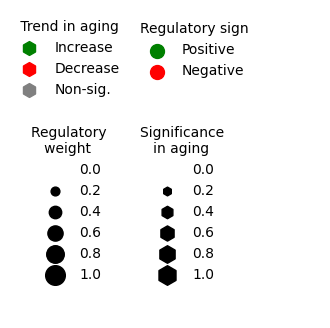

In [72]:
# - plot the legend
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Create a blank figure
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.axis("off")

# 1. Color Legend
palette_sig = {
    "Increase": "green",
    "Decrease": "red",
    "Non-sig.": "gray"    
}

color_legend_sig = [plt.scatter([], [], s=100, marker='h', color=color, label=name) for name, color in palette_sig.items()]
color_legend_sig = ax.legend(handles=color_legend_sig, title=" Trend in aging", loc=(0.0, 0.7), frameon=False)

palette_reg = {
    "Positive": "green",
    "Negative": "red",
    
}
color_legend_reg = [plt.scatter([], [], s=100, color=color, label=name) for name, color in palette_reg.items()]
color_legend_reg = ax.legend(handles=color_legend_reg, title="Regulatory sign", loc=(0.4, 0.76), frameon=False)

# 2. Regulatory Weight Legend (Circle markers)
size_legend_values = np.linspace(0, 1, num=6)
size_legend_handles = [
    plt.scatter([], [], s=s * 200, color="black", label=f"{s:.1f}") for s in size_legend_values
]
size_legend_handle = ax.legend(
    handles=size_legend_handles, title="Regulatory \n   weight", loc=(0.05, 0.1), frameon=False
)

# 3. Ageing Significance Legend (Hexagon markers)
ageing_legend_handles = [
    plt.scatter([], [], s=s * 200, marker="h", color="black", label=f"{s:.1f}") for s in size_legend_values
]
ageing_legend_handle = ax.legend(
    handles=ageing_legend_handles, title="Significance \n   in aging", loc=(0.4, 0.1), frameon=False
)

# Add legends manually
ax.add_artist(color_legend_sig)
ax.add_artist(color_legend_reg)
ax.add_artist(size_legend_handle)

plt.show()

In [73]:
skeleton = pd.read_csv(f'{task_grn_inference_dir}/resources/grn_benchmark/prior//skeleton.csv')
skeleton['link'] = skeleton['source'] + '_' + skeleton['target']

skeleton.head(5)

,Unnamed: 0,source,target,link
0,0,NR2F1,LINC01409,NR2F1_LINC01409
1,1,THRA,LINC01409,THRA_LINC01409
2,2,SREBF1,LINC01409,SREBF1_LINC01409
3,3,ZFY,LINC01409,ZFY_LINC01409
4,4,ZNF460,LINC01409,ZNF460_LINC01409


In [74]:
all_data['link'] = all_data['source'] + '_' + all_data['target']
all_data['in_skeleton'] = all_data['link'].isin(skeleton['link'])

In [75]:
# - merge small modules
all_data_store = []
for cell_type in all_data['cell_type'].unique():
    df_celltype = all_data[all_data['cell_type'] == cell_type].copy()
    # df_celltype = df_celltype[df_celltype['source'] == 'TCF7'] #TODO

    # Identify modules with fewer than 20 TFs and merge them
    tfs_n = df_celltype.groupby('module')['source'].nunique()
    modules_to_merge = tfs_n[tfs_n < 10].index
    df_celltype.loc[df_celltype['module'].isin(modules_to_merge), 'module'] = 'Merged'

    modules = df_celltype['module'].unique()

    df_celltype['module'] = df_celltype['module'].map({module: i for i, module in enumerate(modules)})
    if cell_type not in ['CD8T']:
        df_celltype['module'] = 'All'
    all_data_store.append(df_celltype)

all_data = pd.concat(all_data_store)

In [76]:
# - definition of dotplot
n_top_tfs = 20
n_top_targets = 40

linear_trend_palette = {'Increase': 'green', 'Decrease': 'red', 'Non-Sig': 'gray', 'Inconsistent': 'yellow'}

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

def plot_dotplot(sub_df, title='', figsize=(10, 20), height_ratios=(4, .2), width_ratios=[0.3, 4], ax_main_margin=[0, 0]):
    sub_df=sub_df.sort_values('in_degree_c', ascending=False)
    # sub_df['target'] = pd.Categorical(sub_df['target'], categories=sorted_targets, ordered=True)

    
    # Subset to top TFs and targets
    top_tfs = sub_df.sort_values('meta_p_adj').dropna()['source'].unique()[:n_top_tfs]
    top_targets = sub_df.sort_values('meta_p_adj_target').dropna()['target'].unique()[:n_top_targets]
    sub_df = sub_df[sub_df['source'].isin(top_tfs) & sub_df['target'].isin(top_targets)]
    
    # Compute -log10(meta_p_value) sizes for sources and targets
    sub_df['source_size'] = -np.log10(sub_df['meta_p_adj'])  
    sub_df['target_size'] = -np.log10(sub_df['meta_p_adj_target']) 
    sub_df['regulation_sig'] = sub_df['weight'].apply(lambda x: 'Positive' if x >= 0 else 'Negative')

    n_tfs = len(sub_df['source'].unique())
    n_targets = len(sub_df['target'].unique())
    fig, axes = plt.subplots(figsize=figsize, 
                                nrows=2, ncols=2, 
                                gridspec_kw={'width_ratios': width_ratios, 'height_ratios': height_ratios})
    
    # print(f"n_tfs: {n_tfs} , {figsize}")
    ## --- LEFT PANEL: TF Outdegree & Linear Trend ---
    ax = axes[0, 0]
    sns.scatterplot(data=sub_df, 
                    x=np.zeros(len(sub_df)),  
                    y='source', 
                    size='source_size',  
                    hue='linear_trend', 
                    palette=linear_trend_palette,
                    alpha=0.8, 
                    marker='h',
                    sizes=(10, 100),
                    legend=False,
                    ax=ax)

    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_ylabel("TF", fontsize=11)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.margins(y=ax_main_margin[1])

    ## --- MAIN PLOT: TF-Target Interactions ---
    ax = axes[0, 1]

    # Map True/False to edge colors
    edge_colors = sub_df['in_skeleton'].map({True: 'black', False: 'white'})

    # Plot with edge colors
    sns.scatterplot(data=sub_df, 
                    x='target', 
                    y='source', 
                    size=normalize(sub_df['weight']),
                    hue='regulation_sig',
                    palette={'Positive': 'green', 'Negative': 'red'}, 
                    alpha=0.8, 
                    legend=False,
                    sizes=(10, 100),
                    edgecolor=edge_colors,  # Add edge coloring
                    linewidth=1,  # Adjust for visibility
                    ax=ax)

    ax.set_ylabel("")
    ax.set_xlabel("")
    
    ax.set_title(title, fontsize=12, pad=20)
    ax.tick_params(axis="both", length=0)  
    ax.spines[:].set_visible(False)
    ax.set_yticklabels([], rotation=0)  
    ax.set_xticklabels([], rotation=0)  
    ax.margins(x=ax_main_margin[0], y=ax_main_margin[1])
    ax.grid(True, linestyle="--", alpha=0.5)

    ## --- BOTTOM PANEL: Target Indegree ---
    ax = axes[1, 1]
    sns.scatterplot(data=sub_df, 
                    x='target', 
                    y=np.zeros(len(sub_df)),  
                    size='target_size',  
                    hue='linear_trend_target', 
                    palette=linear_trend_palette,
                    alpha=0.8, 
                    marker='h',
                    sizes=(10, 100),
                    legend=False,
                    edgecolor=None,
                    ax=ax)

    ax.set_yticks([])
    ax.set_ylabel("")
    ax.set_xlabel("Target gene", labelpad=20, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90) 
    ax.margins(x=ax_main_margin[0])
    for label in ax.get_xticklabels():
        label.set_color('#CC79A7' if label.get_text() in tf_all else '#56B4E9')

    # Hide bottom-left panel (empty)
    axes[1, 0].axis("off")
    
    plt.tight_layout()
    plt.show()

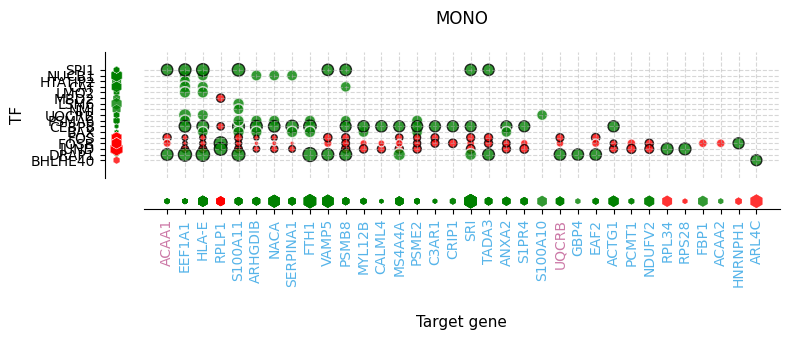

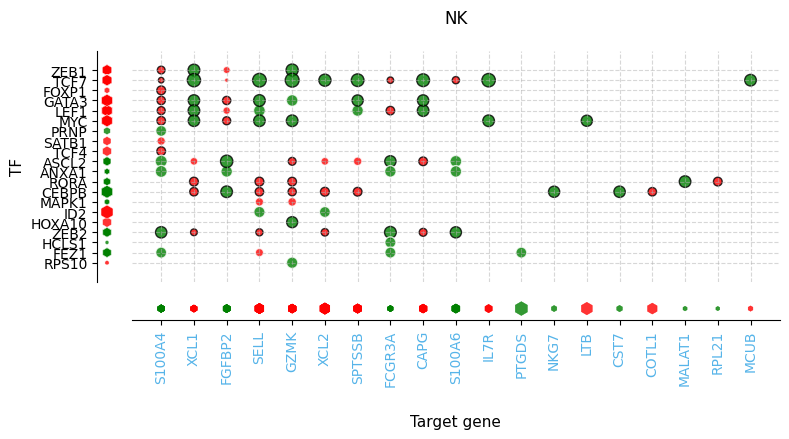

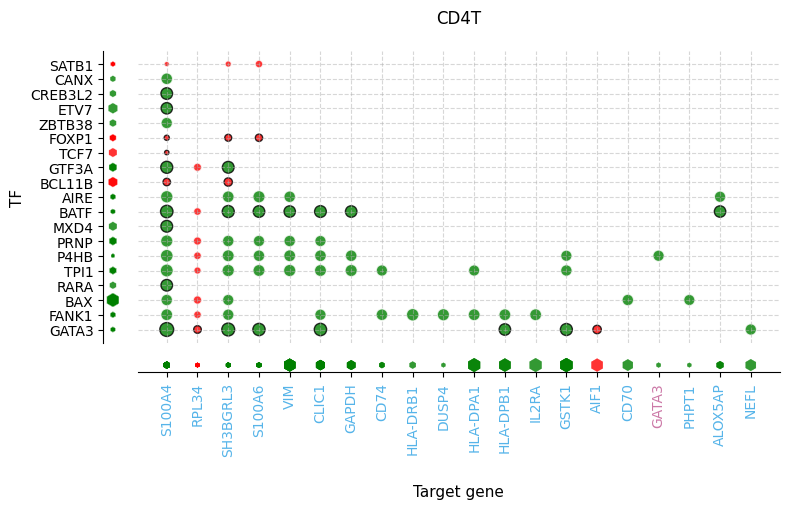

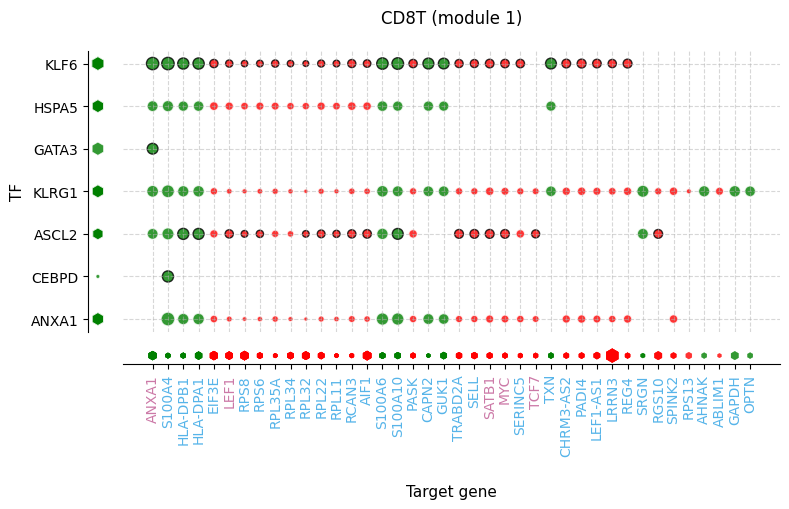

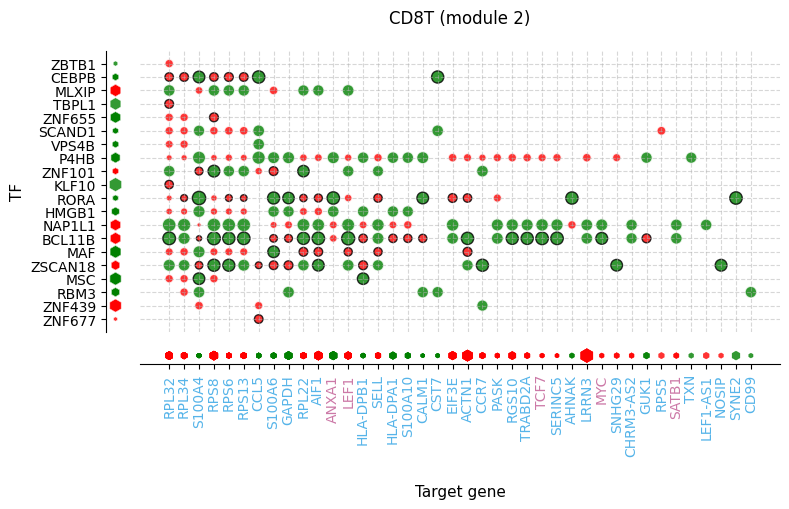

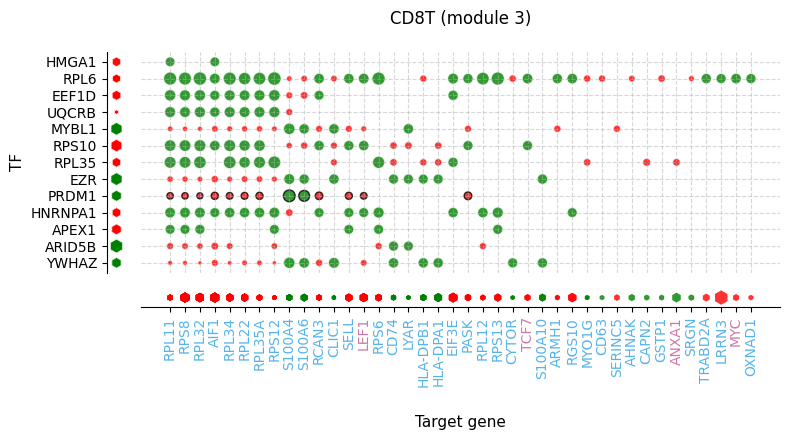

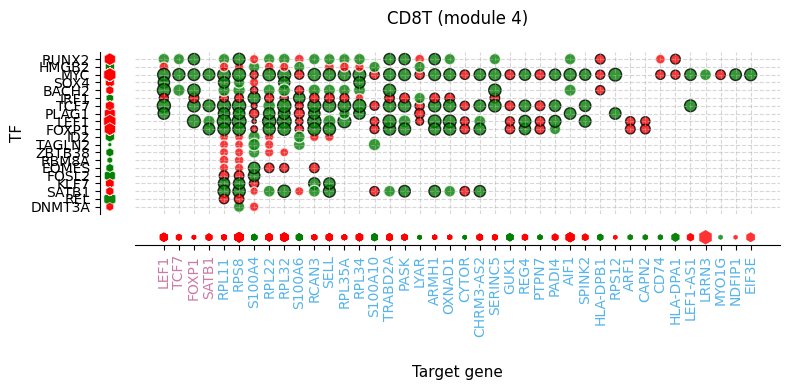

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


plot_dotplot(all_data[all_data['cell_type']=='MONO'], title='MONO', figsize=(8, 3.5), height_ratios=(4, .5), width_ratios=[0.15, 4], ax_main_margin=(0.04, .2))
plot_dotplot(all_data[all_data['cell_type']=='NK'], title='NK', figsize=(8, 4.5), height_ratios=(4, .4), width_ratios=[0.12, 4], ax_main_margin=(0.05, .1))
plot_dotplot(all_data[all_data['cell_type']=='CD4T'], title='CD4T', figsize=(8, 5.2), height_ratios=(4, .2), width_ratios=[0.12, 4], ax_main_margin=(0.05, .05))

df_cell_type = all_data[all_data['cell_type']=='CD8T']
plot_dotplot(df_cell_type[df_cell_type['module']==0], title='CD8T (module 1)', figsize=(8, 5.2), height_ratios=(4, .25), width_ratios=[0.12, 4], ax_main_margin=(0.05, .05))
plot_dotplot(df_cell_type[df_cell_type['module']==1], title='CD8T (module 2)', figsize=(8, 5.2), height_ratios=(4, .25), width_ratios=[0.12, 4], ax_main_margin=(0.05, .05))
plot_dotplot(df_cell_type[df_cell_type['module']==2], title='CD8T (module 3)', figsize=(8, 4.5), height_ratios=(4, .35), width_ratios=[0.12, 4], ax_main_margin=(0.05, .05))
plot_dotplot(df_cell_type[df_cell_type['module']==3], title='CD8T (module 4)', figsize=(8, 4), height_ratios=(4, .4), width_ratios=[0.12, 4], ax_main_margin=(0.05, .05))



# GSEA

In [78]:
# remove those that were not consistent 
df = add_supp_cols(stats_all_sig, pval_col='meta_p_adj', slope_col='slope')[['tf', 'cell_type', "meta_p_adj", 'linear_trend', 'neg_log10_adj_pval']]

stats_all_sig_consistent = df[df['linear_trend'] != 'Inconsistent']
stats_all_sig_consistent.head(5)

,tf,cell_type,meta_p_adj,linear_trend,neg_log10_adj_pval
0,BATF,CD4T,1.521981e-16,Increase,15.817591
1,NPDC1,CD4T,1.304561e-14,Increase,13.884536
2,RAN,CD4T,1.391259e-15,Increase,14.856592
3,SP140,CD4T,4.613587e-14,Increase,13.335961
4,ID2,CD4T,9.280180e-11,Increase,10.032444


## Canonical 

In [79]:
# - how many TFs are in canonical pathways -> do not only rely on canonical pathways
tfs = stats_all_sig_consistent['tf'].unique()
np.setdiff1d(tfs, pathways_df.index).shape
print(f'All tfs n {len(tfs)}, TFs not in canonical pathways:', np.setdiff1d(tfs, pathways_df.index).shape)

All tfs n 283, TFs not in canonical pathways: (138,)


In [80]:
import gseapy as gp
from gseapy import barplot, dotplot

res2d_store = []
for cell_type in stats_all_sig_consistent['cell_type'].unique():
    for trend in stats_all_sig_consistent['linear_trend'].unique():
        mask = (stats_all_sig_consistent['cell_type'] == cell_type) & (stats_all_sig_consistent['linear_trend'] == trend)
        stats_df = stats_all_sig_consistent[mask]
        # - prepare
        stats_df = stats_df[['tf', 'meta_p_adj']]
        stats_df = stats_df[~stats_df.duplicated()].reset_index(drop=True)
        # ranked_genes = stats_df.set_index('tf')['meta_p_adj'].sort_values(ascending=True)

        # - EA
        print(f"cell_type: {cell_type}, trend: {trend}, n tfs: {stats_df['tf'].nunique()}")
        np.savetxt('../output/test.csv', stats_df['tf'].unique(), fmt='%s', delimiter=',')
        rr = gp.enrichr(gene_list='../output/test.csv',
                        gene_sets=['MSigDB_Hallmark_2020'], #, 'KEGG_2021_Human'
                        organism='human', 
                        outdir=None, 
                        background=tf_all,
                        )
        res2d = rr.res2d
        res2d = res2d[res2d['Adjusted P-value']<0.05]

        res2d['cell_type'] = cell_type
        res2d['linear_trend'] = trend
        res2d_store.append(res2d)
res2d_all = pd.concat(res2d_store)
res2d_all.head()

cell_type: CD4T, trend: Increase, n tfs: 78
cell_type: CD4T, trend: Decrease, n tfs: 10
cell_type: CD8T, trend: Increase, n tfs: 109
cell_type: CD8T, trend: Decrease, n tfs: 42
cell_type: NK, trend: Increase, n tfs: 21
cell_type: NK, trend: Decrease, n tfs: 24
cell_type: B, trend: Increase, n tfs: 14
cell_type: B, trend: Decrease, n tfs: 14
cell_type: MONO, trend: Increase, n tfs: 97
cell_type: MONO, trend: Decrease, n tfs: 52


,Gene_set,Term,P-value,Adjusted P-value,Old P-value,Old adjusted P-value,Odds Ratio,Combined Score,Genes,cell_type,linear_trend
0,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,0.000030,0.000796,0,0,10.421707,108.401800,PRNP;XBP1;KLF6;BHLHE40;RORA;IKZF2;BATF,CD4T,Increase
1,MSigDB_Hallmark_2020,Hypoxia,0.000041,0.000796,0,0,9.837246,99.419974,PRDX5;KLF6;TPI1;BHLHE40;RORA;NR3C1;FOSL2,CD4T,Increase
2,MSigDB_Hallmark_2020,Estrogen Response Early,0.000482,0.006032,0,0,7.475000,57.093604,KLF10;ELF1;XBP1;BHLHE40;RARA;MYBL1,CD4T,Increase
3,MSigDB_Hallmark_2020,E2F Targets,0.000738,0.006032,0,0,6.787879,48.951339,RAD21;HMGB2;NAP1L1;SMC3;RAN;EZH2,CD4T,Increase
4,MSigDB_Hallmark_2020,Apoptosis,0.000773,0.006032,0,0,8.806262,63.095682,ANXA1;RARA;HMGB2;BAX;SOD1,CD4T,Increase


In [81]:
terms = res2d_all.groupby(['cell_type'])['Term'].apply(list)
print('MONO:', terms['MONO'])
print('NK:',terms['NK'])
print('CD4T:',terms['CD4T'])
print('CD8T:',terms['CD8T'])

MONO: ['Interferon Alpha Response', 'Interferon Gamma Response', 'Myc Targets V1', 'Oxidative Phosphorylation', 'DNA Repair', 'Pperoxisome', 'IL-6/JAK/STAT3 Signaling', 'Reactive Oxygen Species Pathway', 'Allograft Rejection', 'Complement', 'Fatty Acid Metabolism', 'E2F Targets', 'Apoptosis', 'heme Metabolism', 'PI3K/AKT/mTOR  Signaling', 'Inflammatory Response', 'Bile Acid Metabolism', 'Adipogenesis', 'TNF-alpha Signaling via NF-kB', 'IL-2/STAT5 Signaling', 'Inflammatory Response', 'Hypoxia', 'TGF-beta Signaling', 'Estrogen Response Early', 'Apoptosis', 'UV Response Dn', 'p53 Pathway', 'mTORC1 Signaling', 'Estrogen Response Late', 'Cholesterol Homeostasis']
NK: ['Apoptosis', 'IL-2/STAT5 Signaling', 'TNF-alpha Signaling via NF-kB', 'Wnt-beta Catenin Signaling', 'Complement', 'Apoptosis', 'Myc Targets V1', 'Inflammatory Response']
CD4T: ['IL-2/STAT5 Signaling', 'Hypoxia', 'Estrogen Response Early', 'E2F Targets', 'Apoptosis', 'Myc Targets V1', 'mTORC1 Signaling', 'TNF-alpha Signaling vi

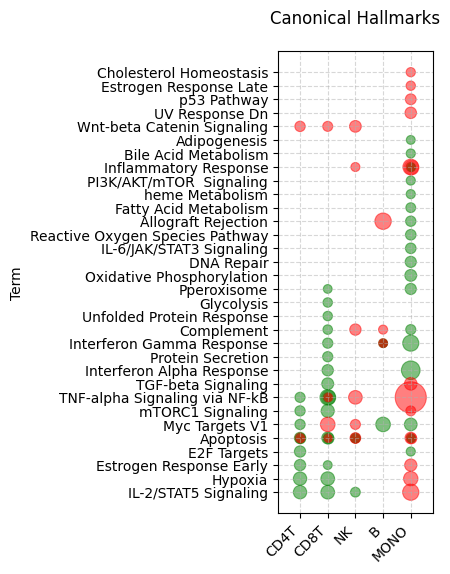

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_enrich(df, ax):
    sizes=None
    # Compute -log10(Adjusted P-value)
    df["neg_log10_padj"] = -np.log10(df["Adjusted P-value"])

    # Identify term-cell type pairs that have both Increase and Decrease
    multi_trend = df.groupby(["Term", "cell_type"])["linear_trend"].nunique()
    multi_trend_pairs = multi_trend[multi_trend > 1].index

    # Set color mapping
    palette = {"Increase": "green", "Decrease": "red"}

    # Scatter plot for each trend (Increase, Decrease)
    for trend, color in palette.items():
        subset = df[df["linear_trend"] == trend]
        ax.scatter(
            subset["cell_type"], subset["Term"], 
            s=subset["neg_log10_padj"] * 30,  # Scale size
            color=color, edgecolors=None,
            label=trend, alpha=0.5,
            linewidth=0.8,
            # sizes=sizes
        )

    # Ensure two separate dots for cases where both Increase & Decrease exist
    for (term, cell_type) in multi_trend_pairs:
        sub = df[(df["Term"] == term) & (df["cell_type"] == cell_type)]
        for _, row in sub.iterrows():
            ax.scatter(
                row["cell_type"], row["Term"],
                s=row["neg_log10_padj"] * 30,
                color=palette[row["linear_trend"]],
                edgecolors=None,
                alpha=0.5,
                linewidth=0,
                # sizes=sizes

            )

    ax.set_xlabel("Cell Type")
    ax.set_ylabel("Term")
    ax.set_xlabel("")
    ax.margins(x=.2)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    # ax.spines[['right', 'top']].set_visible(False)
    # ax.legend(title="Trend", loc=(1.1, .8), frameon=False)

# Create figure
fig, ax = plt.subplots(figsize=(2, 6))
plot_enrich(res2d_all, ax)
plt.title("Canonical Hallmarks", pad=20)
# plt.tight_layout()
plt.show()

In [83]:
tf_acts

AnnData object with n_obs × n_vars = 313 × 393
    obs: 'sample', 'age', 'donor_id', 'cell_count'

# Single cell TF activation

In [ ]:
cell_types = ['CD4T', 'CD8T', 'NK', 'B', 'MONO']

par = {
    # - global vars
    'datasets': ['data1', 'data7_allTPs_jalil'], # data7_allTPs_jalil
    'central_tf_q': .8,
    'predictor_age_q': .8,
    'use_pseudobulk': False,
}
# par['cell_type'] = cell_types[0]

# --------------------------- function
from src.tf_activity.helper import adata_sc_lambda, net_lambda, calculate_tf_activity

# cell_type = par['cell_type']
datasets = par['datasets']
# # --------- load data

# if par['use_pseudobulk']:
#     adata_dict = {dataset: adata_cell_type_lambda(dataset, cell_type) for dataset in datasets}
# else:
#     adata_dict = {dataset: adata_sc_lambda(dataset) for dataset in datasets}
    # adata_dict = {dataset: adata[adata.obs['cell_type']==cell_type] for dataset, adata in adata_dict.items()}
    
# ----------- calculate tf activity for all datasets
#  stored as dict where each item is in adata format (obs: age, donor_id, cell_count) and X: tf activity
tf_acts_sc_dict = {}
for dataset in datasets:
    adata = adata_sc_lambda(dataset)
    tf_acts_store = []
    for cell_type in cell_types:
        nets_dict = {dataset: net_lambda(dataset, cell_type) for dataset in datasets}
        print(f'dataset: {dataset}, cell_type: {cell_type}')
        adata_sub = adata[adata.obs['cell_type'] == cell_type]
        tf_acts = calculate_tf_activity(adata_sub, nets_dict[dataset])
        tf_acts.obs['cell_type'] = cell_type
        print(tf_acts.shape)
        tf_acts_store.append(tf_acts)
    print('Concatenating...')
    tf_acts = ad.concat(tf_acts_store, join="outer")
    print(tf_acts.shape)
    tf_acts_sc_dict[dataset] = tf_acts

In [115]:

tf_act_std_dict = {}
for dataset, adata in tf_acts_sc_dict.items():
    df = pd.DataFrame(adata.X, index=adata.obs.index, columns=adata.var_names)
    genes = df.columns
    # Add metadata
    df["age"] = adata.obs["age"].values.astype(str)
    df["donor_id"] = adata.obs["donor_id"].values.astype(str)

    # Compute standard deviation for each gene per donor-age combination
    std_df = df.groupby(["donor_id", 'age']).std()
    cell_count = df.groupby(["donor_id", 'age']).size()
    std_adata = sc.AnnData(std_df.values)
    
    # Set the new AnnData object's obs and var from the std_df
    std_adata.obs = std_df.reset_index()[["donor_id", 'age']]
    std_adata.obs['cell_count'] = cell_count.values
    std_adata.obs['age'] = pd.to_numeric(std_adata.obs['age'], errors='coerce')
    std_adata.var = pd.DataFrame(index=genes)  # This sets the genes as the variables
    
    # Add the standard deviation data to the dictionary
    tf_act_std_dict[dataset] = std_adata


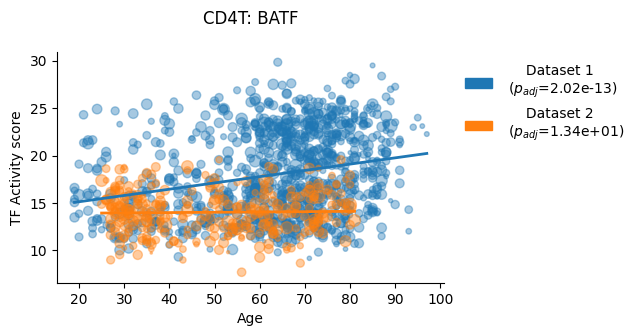

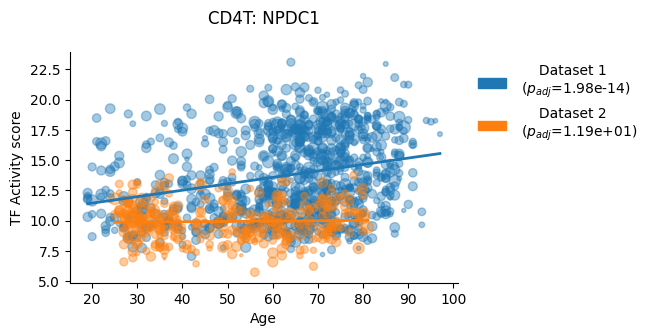

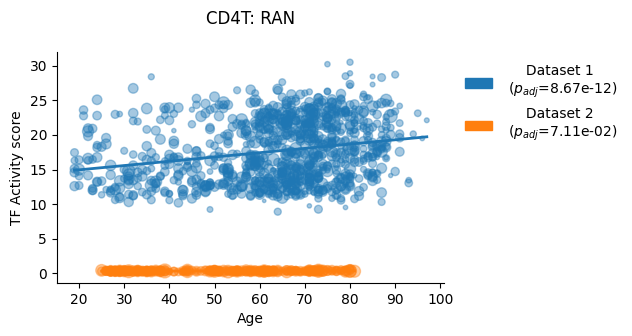

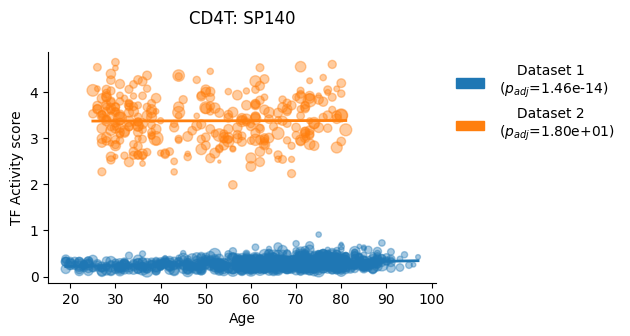

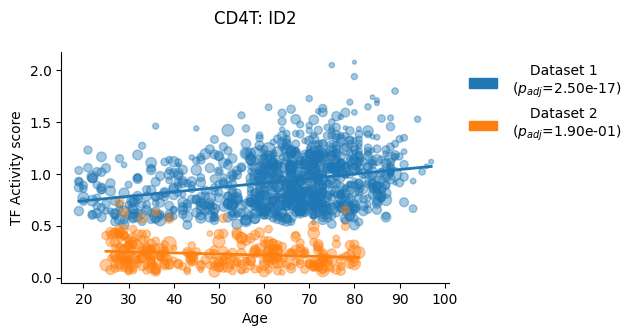

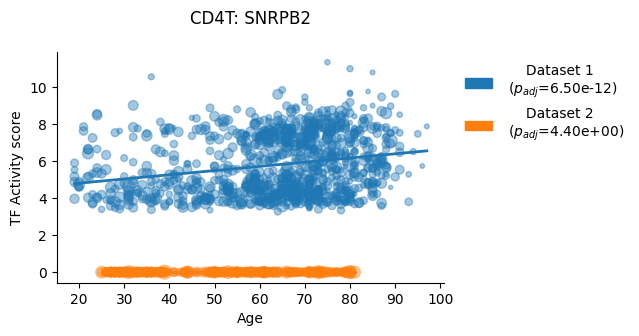

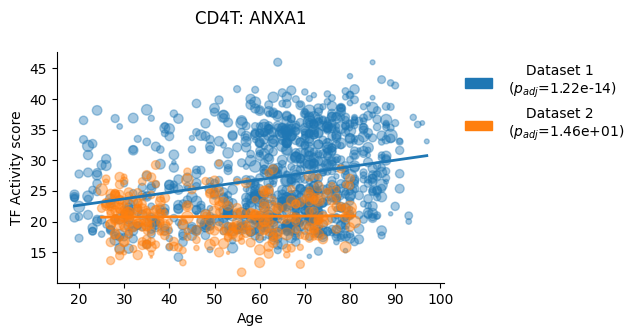

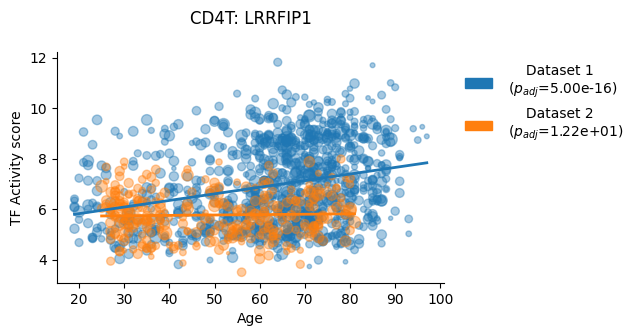

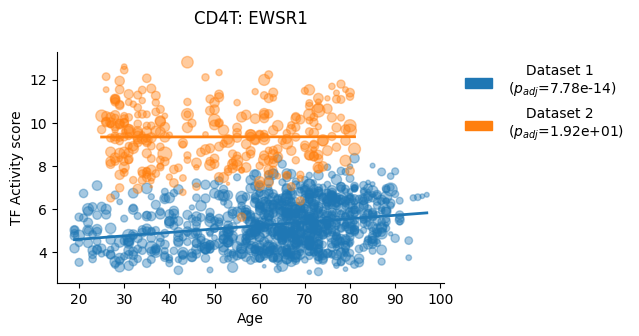

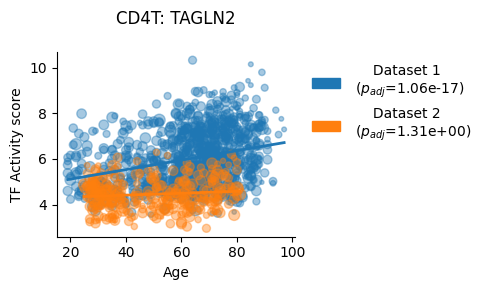

In [117]:
sig_tfs = stats_all_sig[stats_all_sig['cell_type']==cell_type]['tf'].unique()

genes = sig_tfs[:10]

plot_trends(genes, datasets, tf_act_std_dict, datasets_colors, cell_type, surrogate_names=surrogate_names)
plt.tight_layout()

Dataset: data1


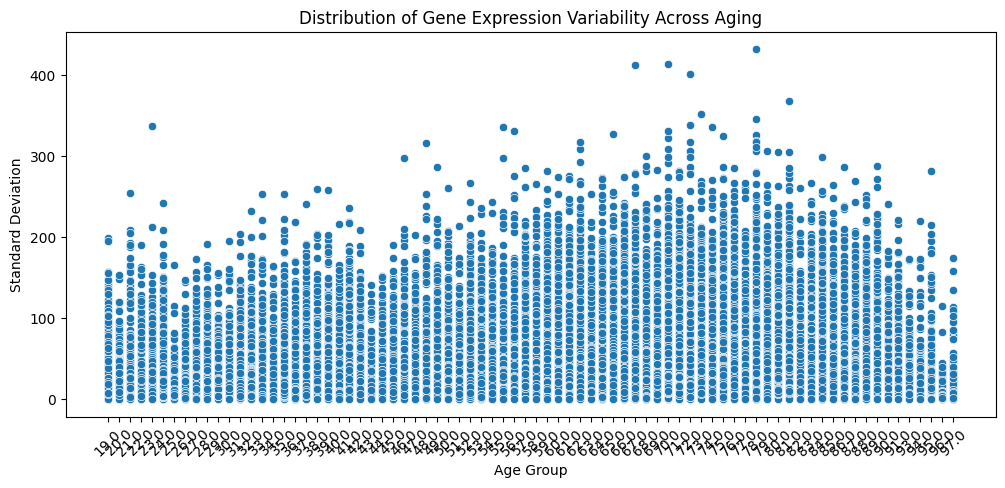

Dataset: data7_allTPs_jalil


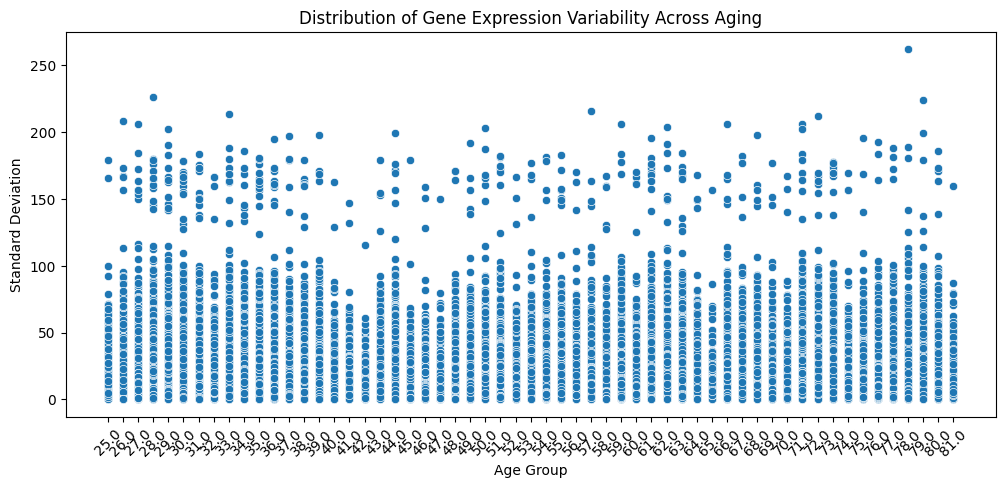

In [37]:
for dataset, std_df in tf_act_std_dict.items():
    print(f"Dataset: {dataset}")
    melted_std = std_df.reset_index().melt(id_vars=["donor_id", "age"], var_name="gene", value_name="std")
    melted_std = melted_std.sort_values('age', ascending=True)
    plt.figure(figsize=(12, 5))
    sns.scatterplot(x="age", y="std", data=melted_std)
    plt.xlabel("Age Group")
    plt.ylabel("Standard Deviation")
    plt.title("Distribution of Gene Expression Variability Across Aging")
    plt.xticks(rotation=45)
    plt.show()